In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Option A: upload directly in Colab
from google.colab import files
uploaded = files.upload()  # choose SampleSuperstore.csv when prompted

# Option B: if it's already in Drive, comment out the block above and use:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/SampleSuperstore.csv')

df = pd.read_csv('SampleSuperstore.csv')
df.head()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [2]:
print(df.shape)
print(df.isna().sum())          # confirm no missing values
print(df['Region'].unique())
print(df['Category'].unique())

(9994, 13)
Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
['South' 'West' 'Central' 'East']
['Furniture' 'Office Supplies' 'Technology']


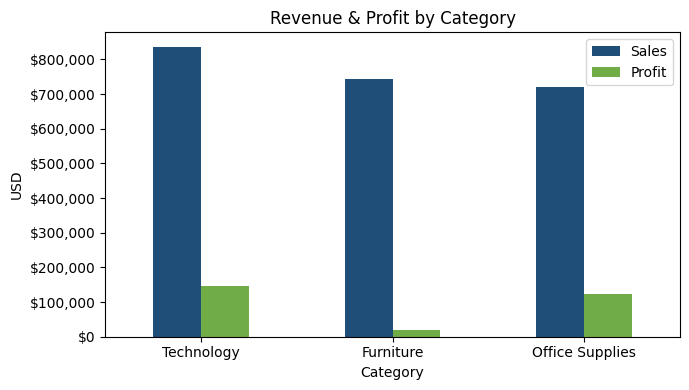

In [3]:
cat = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

fig, ax = plt.subplots(figsize=(7,4))
cat[['Sales', 'Profit']].plot(kind='bar', ax=ax, color=['#1F4E78', '#70AD47'])
ax.set_title('Revenue & Profit by Category')
ax.set_ylabel('USD')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

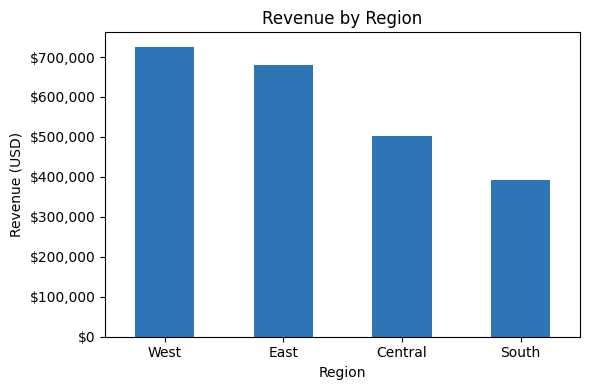

In [4]:
reg = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6,4))
reg.plot(kind='bar', ax=ax, color='#2E75B6')
ax.set_title('Revenue by Region')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

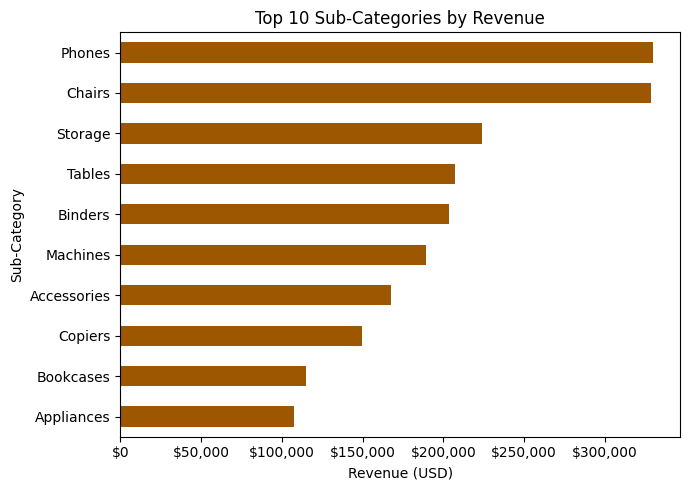

In [5]:
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(7,5))
top_sub.plot(kind='barh', ax=ax, color='#9C5700')
ax.set_title('Top 10 Sub-Categories by Revenue')
ax.set_xlabel('Revenue (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

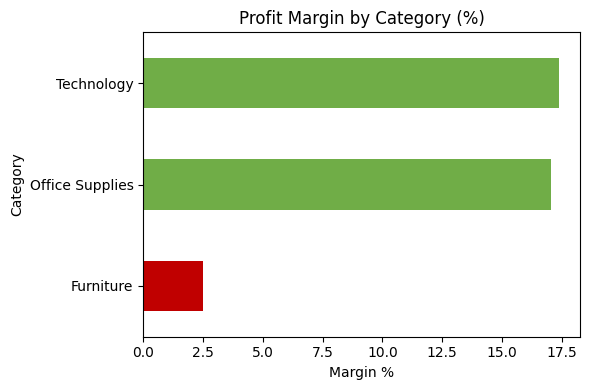

In [6]:
margin = (cat['Profit'] / cat['Sales'] * 100).sort_values()

fig, ax = plt.subplots(figsize=(6,4))
colors = ['#C00000' if v < 5 else '#70AD47' for v in margin]  # flag thin margins in red
margin.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Profit Margin by Category (%)')
ax.set_xlabel('Margin %')
plt.tight_layout()
plt.show()

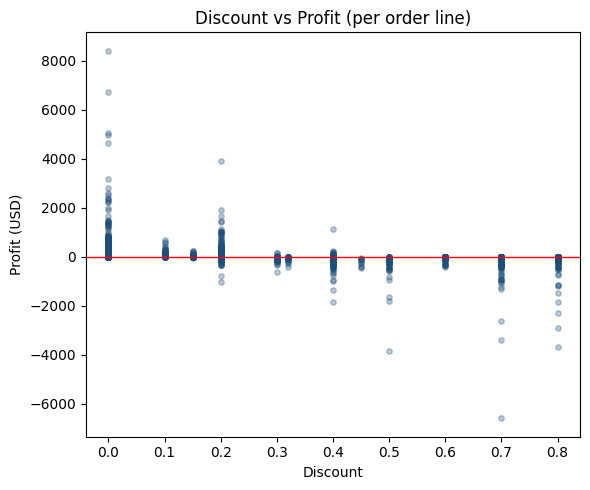

In [7]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.3, s=15, c='#1F4E78')
ax.axhline(0, color='red', linewidth=1)
ax.set_title('Discount vs Profit (per order line)')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit (USD)')
plt.tight_layout()
plt.show()